In [ ]:
# Crear la estructura del proyecto
import os

project_name = "ml-regression-tiempo-modulos"

folders = [
    project_name,
    f"{project_name}/app",
    f"{project_name}/evidencias",
    f"{project_name}/datos",
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Estructura del proyecto creada correctamente")

Estructura del proyecto creada correctamente


In [ ]:
%cd ml-regression-tiempo-modulos

/content/ml-regression-tiempo-modulos


#Fase 1
## 1.1 Definición del problema

Desarrollar un modelo de machine learning capaz de predecir el tiempo estimado en días para desarrollar módulos de software, considerando diversas características del módulo como el número de interfaces de usuario, la cantidad de funcionalidades backend, el nivel de complejidad y las horas disponibles de trabajo por día.

En una empresa con un único desarrollador, el avance del proyecto depende directamente de su disponibilidad, ya que no es posible reducir el tiempo mediante trabajo en paralelo. Por esta razón, un modelo de regresión lineal resulta adecuado para estimar cómo el tiempo de desarrollo aumenta de manera proporcional conforme crece la cantidad y complejidad de las funcionalidades.

En conclusión, el modelo permite realizar estimaciones más objetivas del tiempo de desarrollo, facilitando la planificación de actividades y una mejor estimación de los tiempos de entrega.

Este modelo será desplegado posteriormente mediante una API desarrollada con FastAPI y empaquetado en un contenedor Docker, con el objetivo de validar su funcionamiento en un entorno local y documentar su posible despliegue en la nube.


In [ ]:
# Importar librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

In [ ]:
np.random.seed(42) # garantizar reproducibilidad

**Generación de datos sintéticos**

Debido a que no se dispone de un historial real de módulos desarrollados, se generó un conjunto de datos sintéticos compuesto por 1,000 módulos de software. Cada registro representa un módulo independiente y contiene características que influyen en su tiempo de desarrollo, como el número de interfaces de usuario, la cantidad de funcionalidades del backend, el nivel de complejidad y las horas disponibles de trabajo por día.

La variable objetivo se calculó mediante una función que simula la relación entre estas variables. Se agrega un pequeño ruido aleatorio para simular la variabilidad de proyectos reales.

Esfuerzo=*(Interfaces×5)+(Funcionalidades×4)+(Complejidad×12*

Cálculo de la duración
Duración (días) =* Esfuerzo (horas) / Horas disponibles por día *


In [ ]:
# Generación de datos sintéticos

datos = []

for i in range(1, 1001):

    complejidad = np.random.randint(1, 6)


    if complejidad == 1:
        interfaces = np.random.randint(1, 4)
        funcionalidades = np.random.randint(2, 6)

    elif complejidad == 2:
        interfaces = np.random.randint(2, 6)
        funcionalidades = np.random.randint(4, 9)

    elif complejidad == 3:
        interfaces = np.random.randint(4, 9)
        funcionalidades = np.random.randint(8, 13)

    elif complejidad == 4:
        interfaces = np.random.randint(6, 11)
        funcionalidades = np.random.randint(12, 17)

    else:
        interfaces = np.random.randint(8, 16)
        funcionalidades = np.random.randint(16, 21)


    horas_dia = np.random.randint(4, 9)

    esfuerzo_horas = (
        interfaces * 5 +
        funcionalidades * 4 +
        complejidad * 12 +
        np.random.normal(0, 5)
    )

    esfuerzo_horas = max(esfuerzo_horas, 8)

    duracion_dias = esfuerzo_horas / horas_dia

    # Se agrega un poco de variación
    duracion_dias += np.random.normal(0, 0.5)

    # Evitar valores negativos
    duracion_dias = max(duracion_dias, 1)


    datos.append({
        "modulo": f"M{i:04}",
        "interfaces_usuario": interfaces,
        "funcionalidades_backend": funcionalidades,
        "complejidad": complejidad,
        "horas_disponibles_dia": horas_dia,
        "duracion_estimada_dias": round(duracion_dias, 2)
    })

# Crear DataFrame
data = pd.DataFrame(datos)

# Mostrar las primeras filas
data.head()

,modulo,interfaces_usuario,funcionalidades_backend,complejidad,horas_disponibles_dia,duracion_estimada_dias
0,M0001,10,14,4,8,19.57
1,M0002,6,12,3,7,16.10
2,M0003,9,19,5,5,35.50
3,M0004,7,16,4,7,20.80
4,M0005,5,7,2,7,9.43


In [ ]:
# Guardar el conjunto de datos
data.to_csv("datos/dataset_sintetico.csv", index=False)

print("Dataset guardado correctamente.")

Dataset guardado correctamente.


# Análisis Exploratorio de Datos Breve



1.   Verificar la estructura del dataset con data.info()
2.   Generar estadísticas descriptivas.
3.   Revisar la distribución de la complejidad (value_counts()).
4.   Visualizar la distribución de la duración estimada con un gráfico histograma.
5.   Analizar la correlación entre las variables mediante una matriz de correlación.

In [ ]:
# info general del dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   modulo                   1000 non-null   object 
 1   interfaces_usuario       1000 non-null   int64  
 2   funcionalidades_backend  1000 non-null   int64  
 3   complejidad              1000 non-null   int64  
 4   horas_disponibles_dia    1000 non-null   int64  
 5   duracion_estimada_dias   1000 non-null   float64
dtypes: float64(1), int64(4), object(1)
memory usage: 47.0+ KB


In [ ]:
# Estadísticas descriptivas
data.describe()

,interfaces_usuario,funcionalidades_backend,complejidad,horas_disponibles_dia,duracion_estimada_dias
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,6.306000,10.586000,3.063000,5.984000,19.584240
std,3.666034,5.438215,1.401069,1.408449,11.171657
min,1.000000,2.000000,1.000000,4.000000,2.170000
25%,3.000000,5.000000,2.000000,5.000000,9.700000
50%,6.000000,11.000000,3.000000,6.000000,18.325000
75%,9.000000,16.000000,4.000000,7.000000,26.770000
max,15.000000,20.000000,5.000000,8.000000,57.170000


In [ ]:
# Distribución de la variable complejidad
data["complejidad"].value_counts().sort_index()

,count
complejidad,
1,184
2,194
3,202
4,215
5,205


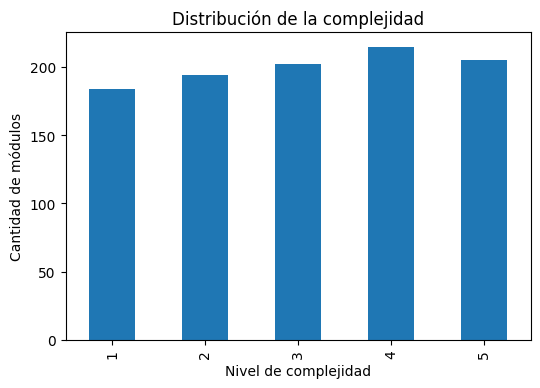

In [ ]:
data["complejidad"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(6,4),
    title="Distribución de la complejidad"
)

plt.xlabel("Nivel de complejidad")
plt.ylabel("Cantidad de módulos")
plt.show()

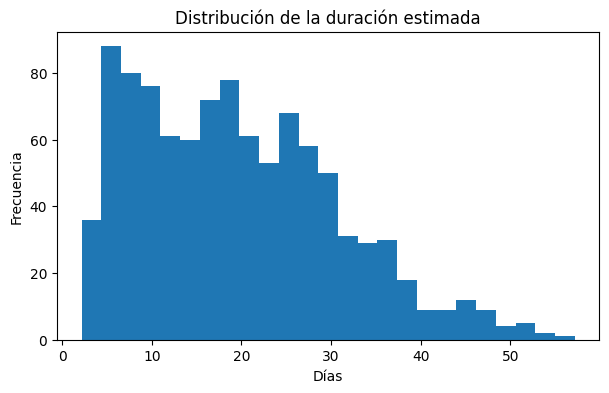

In [ ]:
# Visualización de la duración estimada
plt.figure(figsize=(7,4))

plt.hist(data["duracion_estimada_dias"], bins=25)

plt.title("Distribución de la duración estimada")
plt.xlabel("Días")
plt.ylabel("Frecuencia")

plt.show()

In [ ]:
# Matriz de correlación
correlacion = data.drop(columns=["modulo"]).corr()

correlacion

,interfaces_usuario,funcionalidades_backend,complejidad,horas_disponibles_dia,duracion_estimada_dias
interfaces_usuario,1.000000,0.869554,0.898561,-0.007387,0.820935
funcionalidades_backend,0.869554,1.000000,0.964842,-0.011190,0.847930
complejidad,0.898561,0.964842,1.000000,-0.011156,0.855725
horas_disponibles_dia,-0.007387,-0.011190,-0.011156,1.000000,-0.435097
duracion_estimada_dias,0.820935,0.847930,0.855725,-0.435097,1.000000


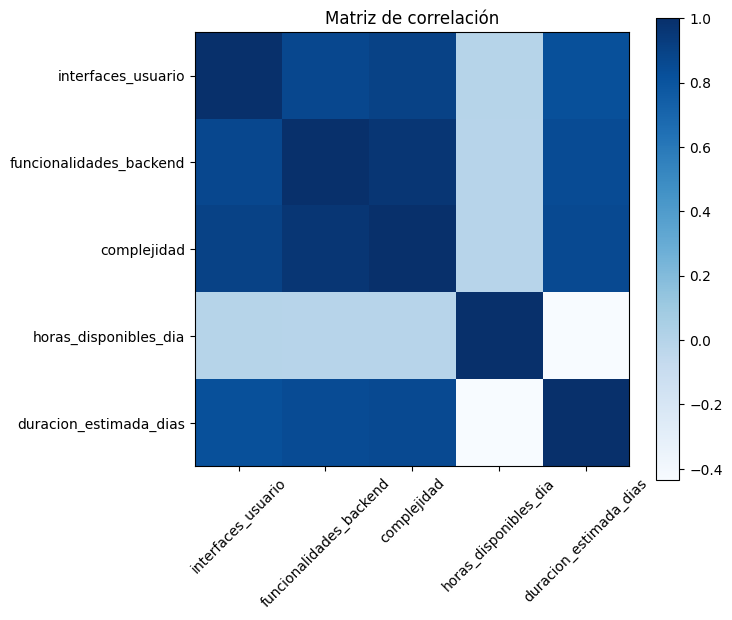

In [ ]:
plt.figure(figsize=(7,6))

plt.imshow(correlacion, cmap="Blues")

plt.colorbar()

plt.xticks(range(len(correlacion.columns)), correlacion.columns, rotation=45)
plt.yticks(range(len(correlacion.columns)), correlacion.columns)

plt.title("Matriz de correlación")

plt.show()

#División de datos

### Variables predictoras


*   interfaces_usuario
*   funcionalidades_backend
*   complejidad
*   horas_disponibles_dia

### Variable objetivo

*   duracion_estimada_dias







In [ ]:
# Variables predictoras (X)
X = data[[
    "interfaces_usuario",
    "funcionalidades_backend",
    "complejidad",
    "horas_disponibles_dia"
]]

# Variable objetivo (y)
y = data["duracion_estimada_dias"]

# División entrenamiento y prueba (Train/test)

Usaremos una división **80% entrenamiento y 20% prueba**.






In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Datos de entrenamiento:", X_train.shape)
print("Datos de prueba:", X_test.shape)

Datos de entrenamiento: (800, 4)
Datos de prueba: (200, 4)


# Entrenamiento del modelo

Se utilizó un modelo de regresión lineal para representar la relación entre el tiempo de desarrollo y la cantidad y complejidad de las funcionalidades.

In [ ]:
# Crear el modelo de Regresión Lineal
modelo = LinearRegression()

# Entrenar
modelo.fit(X_train, y_train)

print("Modelo entrenado correctamente.")

Modelo entrenado correctamente.


# Evaluación del modelo

Utilizaremos las métricas adecuadas para un problema de regresión



*   MAE (Error Absoluto Medio, )
*   RMSE (Raíz del Error Cuadrático Medio)
*   R² (Coeficiente de determinación)



In [ ]:
# Predicciones
y_pred = modelo.predict(X_test)

In [ ]:
# Evaluar métricas

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE : {mae:.2f} días")
print(f"RMSE: {rmse:.2f} días")
print(f"R²  : {r2:.4f}")

MAE : 2.39 días
RMSE: 3.15 días
R²  : 0.9323


In [ ]:
# Comparación valores reales y predichos
resultados = pd.DataFrame({
    "Real": y_test.values,
    "Predicción": np.round(y_pred, 2)
})

resultados.head(10)

,Real,Predicción
0,15.10,18.10
1,38.20,32.05
2,8.84,6.84
3,13.58,14.85
4,7.08,11.28
5,39.69,37.68
6,8.88,6.17
7,9.50,10.85
8,32.00,29.97
9,10.97,9.90


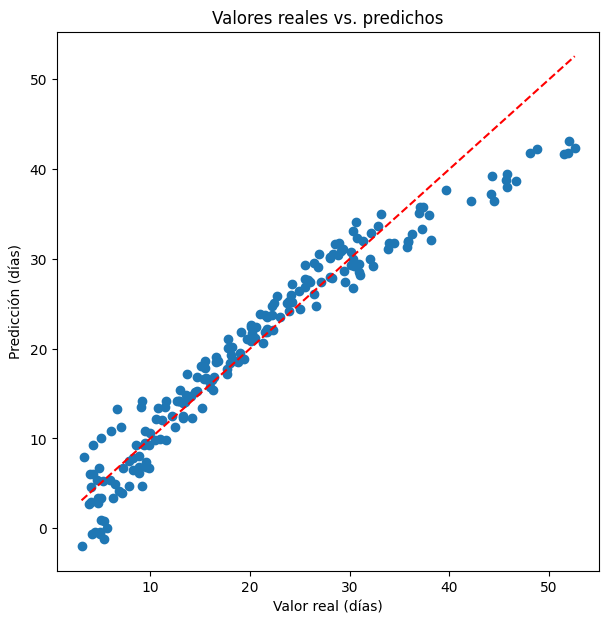

In [ ]:
# Visualización de desempeño del modelo
plt.figure(figsize=(7,7))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Valor real (días)")
plt.ylabel("Predicción (días)")
plt.title("Valores reales vs. predichos")

plt.show()

In [ ]:
print(f"""
Interpretación:
El modelo presentó un buen desempeño predictivo sobre el conjunto de datos sintéticos generado, alcanzando un coeficiente de determinación (R²) de 93.23 %. Además, obtuvo un error absoluto medio (MAE) de 2.39 días, por lo que las predicciones se mantienen cercanas a los valores esperados. Asimismo, el error cuadrático medio (RMSE) fue de 3.15 días, lo que evidencia que los errores de mayor magnitud son reducidos y poco frecuentes, como puede observarse en la gráfica de valores reales frente a predichos. En conclusión, el modelo proporciona estimaciones adecuadas para apoyar la planificación inicial del desarrollo de módulos de software y constituye una base apropiada para su posterior despliegue mediante una API y su contenerización con Docker.
""")


Interpretación:
El modelo presentó un buen desempeño predictivo sobre el conjunto de datos sintéticos generado, alcanzando un coeficiente de determinación (R²) de 93.23 %. Además, obtuvo un error absoluto medio (MAE) de 2.39 días, por lo que las predicciones se mantienen cercanas a los valores esperados. Asimismo, el error cuadrático medio (RMSE) fue de 3.15 días, lo que evidencia que los errores de mayor magnitud son reducidos y poco frecuentes, como puede observarse en la gráfica de valores reales frente a predichos. En conclusión, el modelo proporciona estimaciones adecuadas para apoyar la planificación inicial del desarrollo de módulos de software y constituye una base apropiada para su posterior despliegue mediante una API y su contenerización con Docker.



# Guardado del modelo entrenado

In [ ]:
# Guardar el modelo entrenado

joblib.dump(modelo, "app/modelo.pkl")

print("Modelo guardado correctamente.")

Modelo guardado correctamente.


In [ ]:
# verificar estructura del repositorio

for raiz, carpetas, archivos in os.walk("."):
    print(raiz)
    for archivo in archivos:
        print("   └──", archivo)

.
./datos
   └── dataset_sintetico.csv
./app
   └── modelo.pkl
./evidencias


# Creación de la estructura del proyecto

In [ ]:
# crear carpetas faltantes y archivos faltantes
os.makedirs("docs", exist_ok=True)

# Archivos principales
archivos = [
    "README.md",
    "Dockerfile",
    "requirements.txt",
    "app/main.py",
    "app/metadata_modelo.json",
    "docs/Manual_Despliegue_Nube.md",
    "docs/Validacion_Pruebas.md"
]

for archivo in archivos:
    if not os.path.exists(archivo):
        with open(archivo, "w") as f:
            pass

print("Estructura del proyecto creada correctamente.")


Estructura del proyecto creada correctamente.


In [ ]:
import json

metadata = {
    "nombre_proyecto": "Estimador de tiempo de desarrollo de módulos",
    "version": "1.0.0",
    "fecha_entrenamiento": "2026-07-05",
    "modelo": "Regresión Lineal",
    "framework": "scikit-learn",
    "tipo_problema": "Regresión",
    "variable_objetivo": "duracion_estimada_dias",
    "variables_entrada": [
        "interfaces_usuario",
        "funcionalidades_backend",
        "complejidad",
        "horas_disponibles_dia"
    ],
    "metricas": {
        "MAE": 2.39,
        "RMSE": 3.15,
        "R2": 0.9323
    },
    "descripcion": "Modelo de machine learning para estimar en días la duración del desarrollo de módulos de software con base en sus características principales y la disponibilidad diaria del desarrollador."
}

with open("app/metadata_modelo.json", "w", encoding="utf-8") as file:
    json.dump(metadata, file, indent=4, ensure_ascii=False)

print("Archivo metadata_modelo.json generado correctamente.")

Archivo metadata_modelo.json generado correctamente.


# Pruebas de la API

Verificamos el funcionamiento de la API antes de su contenerización mediante Docker.

In [ ]:
!pip install -r requirements.txt

# Documentación


In [ ]:
%%writefile README.md
# Proyecto: Estimador de Tiempo de Desarrollo de Módulos de Software

## Descripción

Este proyecto implementa un modelo de Regresión Lineal para estimar el tiempo de desarrollo (en días) de módulos de software a partir de sus características principales. El modelo fue entrenado con datos sintéticos y posteriormente desplegado mediante una API REST desarrollada con FastAPI y empaquetada en un contenedor Docker para validar su funcionamiento en un entorno local.


## Objetivo

Desarrollar un modelo de regresión lineal capaz de estimar el tiempo requerido para desarrollar módulos de software considerando las siguientes entradas:

- Número de interfaces de usuario.
- Cantidad de funcionalidades del backend.
- Nivel de complejidad del módulo.
- Horas disponibles de trabajo por día.

Posteriormente, desplegar el modelo mediante una API desarrollada con FastAPI y contenerizar la solución utilizando Docker.



## Tecnologías utilizadas

- Python 3.11
- Scikit-learn 1.6.1
- Pandas 2.2.2
- FastAPI 0.138.0
- Pydantic 2.13.4
- Uvicorn 0.49.0
- Docker Desktop



## Estructura del proyecto


```text
ml-tiempo-modulos/
│
├── app/
│   ├── main.py
│   ├── modelo.pkl
│   └── metadata_modelo.json
│
├── datos/
│   └── dataset_sintetico.csv
│
├── docs/
│   ├── Manual_Despliegue_Nube.md
│   └── Validacion_Pruebas.md
│
├── evidencias/
│
├── Dockerfile
├── requirements.txt
├── README.md
└── .gitignore
```

## Conjunto de datos

El modelo fue entrenado utilizando un conjunto de **1,000 registros sintéticos**, donde cada registro representa un módulo de software con diferentes niveles de complejidad y características de desarrollo.

### Variables de entrada (X)

- Interfaces de usuario.
- Funcionalidades del backend.
- Complejidad.
- Horas disponibles por día.

### Variable objetivo (y)

- Duración estimada del desarrollo (días).

---

## Resultados obtenidos

| Métrica | Valor |
|---------|-------:|
| MAE | 2.39 días |
| RMSE | 3.15 días |
| R² | 0.9323 |

---

##Interpretación:

El modelo alcanzó un coeficiente de determinación (R²) de 93.23 %, lo que indica una buena capacidad para estimar la duración del desarrollo sobre el conjunto de datos sintéticos generado.

---

## API REST

La API desarrollada con FastAPI permite verificar el estado del servicio y realizar predicciones del tiempo estimado de desarrollo mediante solicitudes HTTP.

### Endpoints

| Método | Endpoint | Descripción |
|---------|----------|-------------|
| GET | `/` | Verifica que la API se encuentra disponible. |
| POST | `/predict` | Realiza la predicción estimando la duración del desarrollo de un módulo de software. |

### Ejemplo de solicitud

```json
{
  "interfaces_usuario": 6,
  "funcionalidades_backend": 12,
  "complejidad": 4,
  "horas_disponibles_dia": 8
}
```

### Ejemplo de respuesta

```json
{
  "mensaje": "Predicción realizada correctamente.",
  "duracion_estimada_dias": 18.42,
  "unidad": "días"
}
```

---

## Ejecución con Docker

Construir la imagen:

```bash
docker build -t ml-tiempo-modulos .
```

Ejecutar el contenedor:

```bash
docker run -p 8000:8000 ml-tiempo-modulos
```

Acceder a la documentación interactiva de la API:

```
http://localhost:8000/docs
```

---

## Autor

**Carmen Elizabeth Juárez Mortera**

Proyecto para la fase II de ejecución de modelos de Machine Learning mediante FastAPI y Docker.

Overwriting README.md


In [ ]:
%%writefile docs/Manual_Despliegue_Nube.md
# Manual de Despliegue en Azure Container Apps

## 0. Generales

Para realizar el despliegue es necesario haber construido previamente la imagen Docker del proyecto y contar con una suscripción activa en Microsoft Azure.

---

## 1. Objetivo

El presente documento describe el procedimiento para desplegar en la nube la API del modelo de Regresión Lineal desarrollada con FastAPI y contenerizada mediante Docker. La nube seleccionada es **Azure Container Apps**, un servicio PaaS de Microsoft Azure diseñado para ejecutar aplicaciones basadas en contenedores de forma escalable y administrada.

---

## 2. Arquitectura de despligue

La arquitectura de despliegue propuesta se basa en un contenedor Docker y servicios administrados de Azure.

```text
                   Usuario
                       │
                       ▼
             Azure Container Apps
                       │
                       ▼
                FastAPI + Uvicorn
                       │
                       ▼
          Modelo de Regresión Lineal
                       │
                       ▼
                  modelo.pkl
```

---

## 3. Requerimientos técnicos

### Software requerido

- Docker Desktop
- Azure CLI
- Git
- Navegador Web

### Cuenta de servicios

- Suscripción activa de Microsoft Azure
- Azure Container Registry (ACR)

### Recursos necesarios

- Imagen Docker previamente construida.
- Código fuente del proyecto (Github).
- Archivo Dockerfile.
- Archivo requirements.txt.

---

## 4. Procedimiento de despliegue

### Paso 1. Crear un Resource Group

Ingresar al Portal de Azure y crear un **Resource Group**, el cual permitirá organizar todos los recursos relacionados con el proyecto.

**Figura 1. Creación del Resource Group.**

> *Insertar captura del portal de Azure mostrando la creación del Resource Group.*

---

### Paso 2. Crear un Azure Container Registry (ACR)

Crear un registro de contenedores donde se almacenará la imagen Docker que será utilizada durante el despliegue.

**Figura 2. Creación del Azure Container Registry.**

> *Insertar captura del Azure Container Registry.*

---

### Paso 3. Construir la imagen Docker

Desde la carpeta raíz del proyecto ejecutar:

```bash
docker build -t ml-tiempo-modulos .
```

Una vez finalizada la construcción, verificar que la imagen se encuentre disponible mediante el siguiente comando:

```bash
docker images
```

**Figura 3. Imagen Docker construida correctamente.**

> *Insertar captura de la terminal mostrando la imagen generada.*

---

### Paso 4. Etiquetar la imagen Docker

Asignar una etiqueta compatible con Azure Container Registry.

```bash
docker tag ml-tiempo-modulos estimadoracr.azurecr.io/ml-tiempo-modulos:v1
```

Sustituir **estimadoracr** por el nombre del Azure Container Registry creado previamente.

---

### Paso 5. Autenticarse en Azure

Iniciar sesión mediante Azure CLI.

```bash
az login
```

Posteriormente autenticar el registro de contenedores.

```bash
az acr login --name estimadoracr
```

---

### Paso 6. Publicar la imagen

Enviar la imagen Docker hacia Azure Container Registry.

```bash
docker push estimadoracr.azurecr.io/ml-tiempo-modulos:v1
```

**Figura 4. Publicación de la imagen en Azure Container Registry.**

---

### Paso 7. Crear Azure Container Apps

Desde el Portal de Azure crear una nueva instancia de **Azure Container Apps**.

Durante la configuración seleccionar:

- Azure Container Registry creado previamente.
- Imagen Docker publicada.
- Puerto 8000.
- Configurar el Ingress como External, permitiendo el acceso público a la API.
- CPU y memoria.
- Escalado automático.

**Figura 5. Configuración de Azure Container Apps.**

---

### Paso 8. Obtener la URL pública

Una vez finalizado el despliegue, Azure asignará una dirección pública similar a:

```text
https://ml-tiempo-modulos.azurecontainerapps.io
```

**Figura 6. API desplegada en Azure.**


## 5. Estrategia de despliegue

La estrategia propuesta se basa en la contenerización de la aplicación mediante Docker y su publicación en un servicio **Platform as a Service (PaaS)**. Esta estrategia permite reutilizar la misma imagen Docker construida durante el desarrollo, simplificando el proceso de despliegue y garantizando un entorno de ejecución consistente entre desarrollo y producción.

---

## 6. Conclusiones

Este procedimiento permite desplegar la aplicación desarrollada con FastAPI mediante un contenedor Docker utilizando Azure Container Apps como plataforma PaaS. Gracias a la contenerización, el proceso de implementación resulta reproducible, portable y escalable, facilitando la migración desde un entorno local hacia un entorno de nube sin modificar el código fuente de la aplicación.

Overwriting docs/Manual_Despliegue_Nube.md


In [ ]:
%%writefile docs/Validacion_Pruebas.md
# Documento de Validación y Pruebas

## 1. Objetivo

El presente documento describe las pruebas funcionales realizadas para validar el correcto funcionamiento de la aplicación de machine learning desarrollada.
Las pruebas consideran la construcción de la imagen Docker, la ejecución del contenedor y la verificación del funcionamiento de la API mediante sus dos endpoints.

---

## 2. Ambiente de pruebas

| Componente | Descripción |
|------------|-------------|
| Sistema Operativo | Windows 11 |
| Lenguaje | Python 3.11 |
| Framework API | FastAPI |
| Contenedores | Docker Desktop |
| Modelo ML | Regresión Lineal |
| Puerto utilizado | 8000 |

---

# 3. Pruebas funcionales

## Prueba 1. Construcción de la imagen Docker

**Objetivo**

Verificar que la imagen Docker se construye correctamente utilizando el Dockerfile del proyecto.

**Comando**

```bash
docker build -t ml-tiempo-modulos .
```

**Evidencia**

> Insertar captura de la construcción de la imagen.

---

## Prueba 2. Ejecución del contenedor

**Objetivo**

Comprobar que el contenedor inicia correctamente y publica el servicio en el puerto 8000.

**Comando**

```bash
docker run -p 8000:8000 ml-tiempo-modulos
```

**Evidencia**

> Insertar captura del contenedor en ejecución.

---

## Prueba 3. Endpoint GET /

**Objetivo**

Verificar que la API responde correctamente.

**Método**

GET /

**Evidencia**

> Insertar captura del endpoint.

---

## Prueba 4. Endpoint POST /predict

**Objetivo**

Comprobar que el modelo realiza una predicción correctamente.

**Método**

POST /predict

**Datos de prueba**

```json
{
    "interfaces_usuario": 6,
    "funcionalidades_backend": 12,
    "complejidad": 4,
    "horas_disponibles_dia": 8
}
```

**Evidencia**

> Insertar captura de Swagger mostrando la respuesta.

---

# 4. Pruebas de Casos Extremos  (edge cases)

## Caso 1. Valores mínimos permitidos

```json
{
    "interfaces_usuario": 1,
    "funcionalidades_backend": 1,
    "complejidad": 1,
    "horas_disponibles_dia": 4
}
```

**Resultado esperado**

La API genera una predicción válida.

**Evidencia**

---

## Caso 2. Valores máximos permitidos

```json
{
    "interfaces_usuario": 15,
    "funcionalidades_backend": 20,
    "complejidad": 5,
    "horas_disponibles_dia": 8
}
```

**Resultado esperado**

La API genera una predicción válida.

**Evidencia**

---

## Caso 3. Datos fuera del rango permitido

```json
{
    "interfaces_usuario": -1,
    "funcionalidades_backend": 50,
    "complejidad": 10,
    "horas_disponibles_dia": 15
}
```

**Resultado esperado**

La API rechaza la solicitud mostrando un error de validación HTTP 422.

**Evidencia**
---

# 5. Conclusiones

Las pruebas funcionales y los casos extremos permitieron verificar tanto el comportamiento esperado de la aplicación como el manejo adecuado de entradas inválidas, demostrando que la solución puede ejecutarse de forma consistente en un entorno local mediante Docker.

Overwriting docs/Validacion_Pruebas.md


In [ ]:
%%writefile .gitignore
__pycache__/
*.pyc
.ipynb_checkpoints/
.env

Writing .gitignore
